In [1]:
import logging
import os
import time
import h5py
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import netket as nk
import optax
from scipy.sparse.linalg import eigsh
import pickle
import numpy as np
from NES_VMC_V1 import (
    NESTotalAnsatz,
    NESTotalAnsatz_stable,
    create_single_machine_gauge_fixed,
    Ham_Psi_scaled,
    flatten_batched_pytree,
    NESFermionHopRule,
    ravel_pytree,
)
from NES_VMC_tool import create_gauge_reset_total_machines,NES_loss_energy_stable_gauge,\
    nes_vmc_gradient_stable_gauge,make_grad_fn_gauge,make_qgt_fn_gauge,make_gauge_fn
from H2_631G import SINGLE_SIZE, ha, hi_ext, ext_edges, K, Hatree_Fock,hi,E_fcis
import logging
from NES_VMC_frozen_dynamic import OneWayFreezer

/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: You can use flax.linen, flax.nnx and equinox to define neural networks.

H2 分子基本信息
HF energy = -0.99749729 Ha
Total electrons = (1, 1)
Total basis functions = 4
H₂ FCI 基准能量
E0 = -1.05434745 Ha  |  激发能: 0.0000 eV
E1 = -0.95790573 Ha  |  激发能: 2.6243 eV
E2 = -0.66895227 Ha  |  激发能: 10.4871 eV
E3 = -0.55140192 Ha  |  激发能: 13.6859 eV

HF reference state: [0 0 0 1 0 0 0 1]
single_edges: [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3), (4, 5), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7)]


In [6]:

    
# ====================== 日志配置 ======================
time_str = time.strftime("%y-%m-%d-%H-%M")   # 输出文件名统一时间前缀 YY-DD-HH-MM
logger = logging.getLogger("NES_VMC_K4_gauge_reset")
logger.setLevel(logging.INFO)
logger.propagate = False
logger.handlers.clear()
simple_formatter = logging.Formatter("%(asctime)s %(message)s", datefmt="%y-%d-%H-%M")

os.makedirs("./日志", exist_ok=True)
log_path = f"./日志/{time_str}_nes_vmc_K4_H2_6-31G_gauge_reset.log"
file_handler = logging.FileHandler(log_path, mode="w", encoding="utf-8")
file_handler.setFormatter(simple_formatter)
logger.addHandler(file_handler)

console_handler = logging.StreamHandler()
console_handler.setFormatter(simple_formatter)
logger.addHandler(console_handler)

# ====================== 超参配置 ======================
N_CHAINS = 16
N_SAMPLES_PER_CHAIN = 200
SWEEP_SIZE = 10
N_ITER = 300
Natural_Grad = True
clip_norm = 20.0
lr = 0.1
qgt_diag_shift = 0.1
RESET_PERIOD = 10          # 每隔多少步做一次 gauge reset（30 轮内 3 次）
SAVE_INTERVAL = 20         # 每多少步保存/追加一次 pickle
HISTORY_FILE = f"./data/{time_str}_history_natural_gradient_H2_molecule_K4.pkl"
os.makedirs("./data", exist_ok=True)

# ====================== 模型与采样器 ======================
total_ansatz = NESTotalAnsatz_stable(
    n_spin_orbitals=SINGLE_SIZE,
    n_states=K,
    hidden_dim=SINGLE_SIZE + K,
    rngs=nnx.Rngs(11),
)

g_current = jnp.zeros(K, dtype=jnp.complex64)   # 全局列规范 g，非训练参数，动态传入 jit

(
    total_machine,
    total_matrix_machine,
    total_max_machine,
    total_matrix_machine_raw,
    total_graphdef,
    total_params,
) = create_gauge_reset_total_machines(total_ansatz, Hatree_Fock)

single_machine_list = [
    create_single_machine_gauge_fixed(ansatz, Hatree_Fock)[0]
    for ansatz in total_ansatz.single_ansatz_list
]

grad_fn = make_grad_fn_gauge(
    ha,
    total_matrix_machine,
    total_max_machine,
    total_machine,
    single_machine_list,
)
qgt_fn = make_qgt_fn_gauge(total_machine)

gauge_fn, col_mean_fn = make_gauge_fn(total_ansatz, Hatree_Fock)

nes_rule = NESFermionHopRule(edges=ext_edges, K=K, single_size=SINGLE_SIZE)
nes_sampler = nk.sampler.MetropolisSampler(
    hilbert=hi_ext,
    rule=nes_rule,
    n_chains=N_CHAINS,
    sweep_size=SWEEP_SIZE,
)

# FCI 精确参考能量
exact_eigvals = E_fcis

# ====================== 优化器 ======================
optimizer = optax.chain(
    optax.clip_by_global_norm(clip_norm),
    optax.sgd(learning_rate=lr),
)
opt_state = optimizer.init(total_params)

sampler_rng = jax.random.PRNGKey(21)


def sample_machine(params, sigma):
    """双参数封装：采样只需要 |Ψ|² 的转移率，全局列规范 g 是常数平移，不影响 ratio。
    闭包每次调用读取 g_current 的最新值（g 作为动态参数传入 jit）。"""
    return total_machine(params, sigma, g_current)


sampler_state = nes_sampler.init_state(sample_machine, total_params, sampler_rng)

# ====================== 训练循环 ======================
logger.info("\n" + "=" * 60)
logger.info("开始多链 NES-VMC 训练 | P8: 双侧一致列规范 + 周期性 gauge reset")
logger.info(f"""超参数配置:\n
N_CHAINS ={N_CHAINS}\n
N_SAMPLES_PER_CHAIN ={N_SAMPLES_PER_CHAIN}\n
SWEEP_SIZE = {SWEEP_SIZE}\n
N_ITER = {N_ITER}\n
Natural_Grad = {Natural_Grad}\n
clip_norm = {clip_norm}\n
lr = {lr}\n
qgt_diag_shift = {qgt_diag_shift}\n
RESET_PERIOD = {RESET_PERIOD}\n       
SAVE_INTERVAL = {SAVE_INTERVAL}\
""")

logger.info("=" * 60)
logger.info(
    f"精确CAS基准：基态={exact_eigvals[0]:.8f} Ha | 1激发={exact_eigvals[1]:.8f} Ha"
    f"|2激发={exact_eigvals[2]:.8f} Ha|3激发={exact_eigvals[3]:.8f} Ha|"
)
logger.info(f"理论 Loss 上限：{sum(exact_eigvals[0:K]):.8f} ")
logger.info(f"超参：clip_norm={clip_norm}, lr={lr}, QGT diag_shift={qgt_diag_shift}, RESET_PERIOD={RESET_PERIOD}")

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

loss_history = []
logpsi_history = []
steps_history = []
logpsi_mean_history = []
logpsi_min_history = []
logpsi_max_history = []
grad_norm_raw_history = []
grad_norm_nat_history = []
E_L_real_history = []
E_L_imag_history = []
params_history = []
Energy_levels_history = []


start_time = time.time()

# ====================== 初始化/加载 pickle 历史文件 ======================
# 先尝试只读探测已有数据，支持断点续训
first_step = None
last_step = None
if os.path.exists(HISTORY_FILE):
    try:
        with open(HISTORY_FILE, "rb") as f:
            history = pickle.load(f)
        if history.get("steps"):
            last_step = int(history["steps"][-1])
            first_step = int(history["steps"][0])
            logger.info(f"检测到已有历史文件，上次保存 step={last_step}，将从 step={last_step + 1} 继续")
        else:
            logger.info("检测到历史文件但为空，将从头开始")
    except Exception as e:
        logger.warning(f"读取历史文件失败（可能损坏），将覆盖写入: {e}")
# ====================== 初始化结束 ======================


26-08-18-09 
26-08-18-09 开始多链 NES-VMC 训练 | P8: 双侧一致列规范 + 周期性 gauge reset
26-08-18-09 超参数配置:

N_CHAINS =16

N_SAMPLES_PER_CHAIN =200

SWEEP_SIZE = 10

N_ITER = 300

Natural_Grad = True

clip_norm = 20.0

lr = 0.1

qgt_diag_shift = 0.1

RESET_PERIOD = 10
       
SAVE_INTERVAL = 20
26-08-18-09 ============================================================
26-08-18-09 精确CAS基准：基态=-1.05434745 Ha | 1激发=-0.95790573 Ha|2激发=-0.66895227 Ha|3激发=-0.55140192 Ha|
26-08-18-09 理论 Loss 上限：-3.23260738 
26-08-18-09 超参：clip_norm=20.0, lr=0.1, QGT diag_shift=0.1, RESET_PERIOD=10


In [3]:

for step in range(N_ITER):
    params_history.append(total_params)
    # 1. 采样
    samples_raw, sampler_state = nes_sampler.sample(
        machine=sample_machine,
        parameters=total_params,
        state=sampler_state,
        chain_length=N_SAMPLES_PER_CHAIN,
    )
    samples = samples_raw.reshape(-1, hi_ext.size)
    x_batch = samples.reshape(-1, K, SINGLE_SIZE)

    # 2. 梯度与损失
    grad_raw, loss_mean, E_L_mean, aux = grad_fn(total_params, x_batch, g_current)

    grad_raw_flat, unravel_fn = ravel_pytree(grad_raw)
    grad_norm_raw = jnp.linalg.norm(grad_raw_flat)
    grad_update = grad_raw

    has_nan = bool(jnp.any(jnp.isnan(grad_raw_flat)))
    if has_nan or grad_norm_raw > 5000.0:
        logger.warning(f"【Step {step} 告警】梯度异常！nan={has_nan}, raw_grad_norm={grad_norm_raw:.2f}")

    # 3. QGT 自然梯度
    if Natural_Grad:
        qgt_reg_mat = qgt_fn(total_params, x_batch, qgt_diag_shift, g_current)
        ng_flat = jnp.linalg.solve(qgt_reg_mat, grad_raw_flat)
        grad_update = unravel_fn(ng_flat)
        grad_norm_natural = jnp.linalg.norm(ng_flat)
    else:
        grad_norm_natural = grad_norm_raw

    # 4. 优化器内部完成梯度裁剪 + SGD 更新
    updates, opt_state = optimizer.update(grad_update, opt_state, total_params)
    total_params = optax.apply_updates(total_params, updates)

    grad_norm_clipped = min(float(grad_norm_natural), clip_norm)

    # 5. 能量监控：E_L 矩阵本征值
    eig_vals, _ = jnp.linalg.eig(E_L_mean)
    eig_vals = eig_vals[jnp.argsort(eig_vals.real)]

    # 6. 波函数与Ψ矩阵条件数监控（含 gauge 的值）
    log_Psi_batch = total_machine(total_params, x_batch, g_current)
    x_single = x_batch[0:1, ...]
    psi_mat = total_matrix_machine(total_params, x_single, g_current)[0]
    psi_cond = jnp.linalg.cond(psi_mat)

    gauge_now = float(jnp.real(gauge_fn(total_params, x_batch)))          # RAW L 的行规范坐标
    g_abs = float(jnp.linalg.norm(g_current))

    # 7. 日志（格式与 GaugeFixing00_K4_LiH_STO-3G.log 对齐）
    logger.info(f"[Step {step:3d}] logΨ: mean={log_Psi_batch.mean():.3f} | min={log_Psi_batch.min():.3f} | max={log_Psi_batch.max():.3f}")
    logger.info(f"梯度监控 | raw={grad_norm_raw:.4f} | natural={grad_norm_natural:.4f} | clipped={grad_norm_clipped:.4f}(上限{clip_norm})")
    logger.info(f"原始规范坐标 G(Re Σrow_mean) = {gauge_now:+.4f} | 累计|g| = {g_abs:.4f}")
    logger.info(f"Ψ矩阵条件数 cond(Ψ) = {psi_cond:.2e}")
    logger.info(
        f"Loss={loss_mean:.6f} | E0={eig_vals[0]:.8f} | E1={eig_vals[1]:.8f}"
        f"|E2={eig_vals[2]:.8f}|E3={eig_vals[3]:.8f}"
    )
    logger.info("#-----------------------------------------#")

    # 记录曲线数据（reset 发生在 step+1 边界，曲线上可直接观察回退）
    loss_history.append(float(jnp.real(loss_mean)))
    logpsi_history.append(float(jnp.real(log_Psi_batch.mean())))
    steps_history.append(step)

    # 记录监控数据（用于 pickle 保存）
    logpsi_mean_history.append(float(jnp.real(log_Psi_batch.mean())))
    logpsi_min_history.append(float(jnp.real(log_Psi_batch.min())))
    logpsi_max_history.append(float(jnp.real(log_Psi_batch.max())))
    grad_norm_raw_history.append(float(grad_norm_raw))
    grad_norm_nat_history.append(float(grad_norm_natural))
    E_L_real_history.append(float(jnp.real(jnp.trace(E_L_mean))))
    E_L_imag_history.append(float(jnp.imag(jnp.trace(E_L_mean))))
    Energy_levels_history.append(eig_vals[:K])
    

    # 每 SAVE_INTERVAL 步保存/追加一次 pickle
    if (step + 1) % SAVE_INTERVAL == 0:
        history = {
            "steps": [int(s) for s in steps_history],
            "logpsi_mean": logpsi_mean_history,
            "logpsi_min": logpsi_min_history,
            "logpsi_max": logpsi_max_history,
            "grad_norm_raw": grad_norm_raw_history,
            "grad_norm_natural": grad_norm_nat_history,
            "E_L_real": E_L_real_history,
            "E_L_imag": E_L_imag_history,
            "loss": loss_history,
            "first_step": first_step if first_step is not None else 0,
            "save_interval": SAVE_INTERVAL,
            "Energy_levels": Energy_levels_history,
            "params": params_history,
        }
        
        
        with open(HISTORY_FILE, "wb") as f:
            pickle.dump(history, f)
        logger.info(f"[保存] Step {step} → pickle 文件已更新 ({len(steps_history)} 条记录)")

    # 8. 周期性 gauge reset：把 raw L 的列均值吸收进全局 g（双侧规范，物理不变）
    if (step + 1) % RESET_PERIOD == 0:
        new_col_mean = col_mean_fn(total_params, x_batch)   # (K,) 复数：当前列均值
        g_current = new_col_mean                # 模块级变量直接更新
        absorbed = float(jnp.sum(jnp.real(new_col_mean)))
        logger.info(
            f"[GaugeReset@{step + 1}] 吸收 Δg = Σ Re(col_mean) = {absorbed:+.4f} "
            f"| 新|g| = {float(jnp.linalg.norm(g_current)):.4f}"
        )

end_time = time.time()
logger.info(f"训练耗时：{end_time - start_time:.2f} 秒")
logger.info("\n" + "=" * 60)
logger.info("训练完成!")
logger.info("=" * 60)

# 训练结束后做最后一次写入确保数据完整
history = {
    "steps": [int(s) for s in steps_history],
    "logpsi_mean": logpsi_mean_history,
    "logpsi_min": logpsi_min_history,
    "logpsi_max": logpsi_max_history,
    "grad_norm_raw": grad_norm_raw_history,
    "grad_norm_natural": grad_norm_nat_history,
    "E_L_real": E_L_real_history,
    "E_L_imag": E_L_imag_history,
    "loss": loss_history,
    "first_step": first_step if first_step is not None else 0,
    "save_interval": SAVE_INTERVAL,
    "Energy_levels": Energy_levels_history,
    "params": params_history,
    
}
with open(HISTORY_FILE, "wb") as f:
    pickle.dump(history, f)
logger.info(f"[保存] 训练结束，pickle 最终写入 {len(steps_history)} 条记录 → {HISTORY_FILE}")



NameError: name 'N_ITER' is not defined

In [ ]:
# ====================== 保存曲线图：Loss-step 与 logΨ mean-step ======================
def Loss_mean_curve(y_values, ylabel, title, fig_path):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(steps_history, y_values, marker="o", markersize=3, linewidth=1.2)
    for r in range(RESET_PERIOD, N_ITER + 1, RESET_PERIOD):
        ax.axvline(r - 0.5, color="red", linestyle="--", alpha=0.6)
    ax.set_xlabel("Step")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return fig_path

NameError: name 'steps_history' is not defined

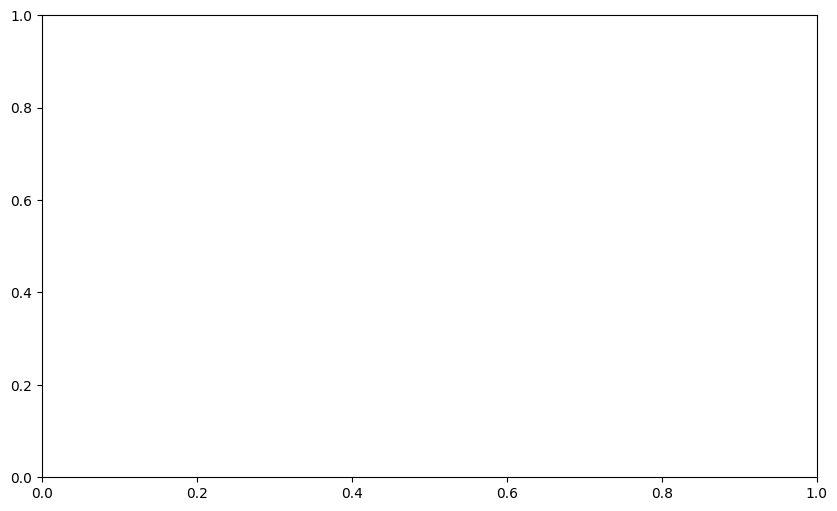

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(steps_history, y_values, marker="o", markersize=3, linewidth=1.2)
for r in range(RESET_PERIOD, N_ITER + 1, RESET_PERIOD):
    ax.axvline(r - 0.5, color="red", linestyle="--", alpha=0.6)
ax.set_xlabel("Step")
ax.set_ylabel(ylabel)
ax.set_title(title)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.close(fig)
return fig_path

In [8]:
# ====================== 保存曲线图：Loss-step 与 logΨ mean-step ======================
def _save_curve(y_values, ylabel, title, fig_path):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(steps_history, y_values, marker="o", markersize=3, linewidth=1.2)
    for r in range(RESET_PERIOD, N_ITER + 1, RESET_PERIOD):
        ax.axvline(r - 0.5, color="red", linestyle="--", alpha=0.6)
    ax.set_xlabel("Step")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return fig_path

loss_fig_path = _save_curve(
    loss_history,
    "Loss",
    f"NES-VMC LiH K=4 Loss curve (P8 gauge reset, N_ITER={N_ITER}, RESET_PERIOD={RESET_PERIOD})",
    f"./日志/[Loss]{time_str}_loss_curve_gauge_reset_min120.png",
)
logger.info(f"Loss 曲线已保存: {loss_fig_path}")

logpsi_fig_path = _save_curve(
    logpsi_history,
    "log Psi mean (Re)",
    f"NES-VMC LiH K=4 logΨ mean curve (P8 gauge reset, N_ITER={N_ITER}, RESET_PERIOD={RESET_PERIOD})",
    f"./日志/[logPsi]{time_str}_logPsi_mean_curve_gauge_reset_min120.png",
)
logger.info(f"logΨ mean 曲线已保存: {logpsi_fig_path}")
logger.info(f"Loss 曲线已保存: {loss_fig_path}")




/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/ipykernel_89893/3758450332.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
26-08-18-14 Loss 曲线已保存: ./日志/[Loss]26-09-08-18-09_loss_curve_gauge_reset_min120.png
26-08-18-14 logΨ mean 曲线已保存: ./日志/[logPsi]26-09-08-18-09_logPsi_mean_curve_gauge_reset_min120.png
26-08-18-14 Loss 曲线已保存: ./日志/[Loss]26-09-08-18-09_loss_curve_gauge_reset_min120.png


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

os.makedirs("./日志", exist_ok=True)

plt.rcParams.update({
    "font.family": "Arial",
    "mathtext.fontset": "cm",
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
})

fig, ax = plt.subplots(figsize=(8, 6))
step_index = 299
steps_slice = steps_history[:step_index]
energy_arr = np.array(Energy_levels_history)[:step_index, :]
color_palette = ["#1f77b4","#ff7f0e","#2ca02c","#d62728"]

# ============ 主图：能量曲线 ============
for energy_index in range(K):
    c = color_palette[energy_index % len(color_palette)]
    ax.plot(steps_slice, energy_arr[:, energy_index],
            marker="o", markersize=2.5, markevery=10,
            linewidth=1.2, color=c, label=f"$E_{energy_index}$ (NES-VMC)")
    ax.axhline(exact_eigvals[energy_index], color=c, linestyle="--", alpha=0.7, label=f"$E_{energy_index}$ (CAS Exact)")

ax.set_ylim(-1.5, 0.0)
ax.set_xlabel("Optimization step")
ax.set_ylabel("Energy Level (Ha)")
ax.legend(loc="lower right")
ax.set_title(f'NES-VMC (K={K}) $H_2$ Energy Levels Curve ')
# ============ 内嵌子图 inset_axes ============
# 参数：宽度40%主图宽度，高度35%主图高度；位置 upper left / upper right
ax_inset = inset_axes(
    ax,
    width="40%",
    height="25%",
    loc="lower left",
    bbox_to_anchor=(0.54, 0.7, 1, 1),   # 4‑tuple！
    bbox_transform=ax.transAxes,
    borderpad=0
)

#ax_inset.set_title(f'NES-VMC (K={K}) LiH Energy Levels Difference (Inset)')

# 绘制误差 ΔE = E_vmc − E_exact
for energy_index in range(K):
    c = color_palette[energy_index % len(color_palette)]
    delta_E = energy_arr[:, energy_index] - exact_eigvals[energy_index]
    ax_inset.plot(steps_slice, delta_E, color=c, marker=".", markersize=1.5, markevery=5, linewidth=0.8)
    ax_inset.set_ylim(0.0, 0.002)

ax_inset.set_xlabel("Step", fontsize=8)
ax_inset.set_ylabel(r"$\Delta E$ (Ha)", fontsize=8)
ax_inset.set_title(f'NES-VMC (K={K}) $H_2$ Energy Levels Difference', fontsize=8)
ax_inset.tick_params(axis='both', labelsize=7)


# ---- 新增：0.0016以下浅蓝色填充 + 阈值虚线 ----
ax_inset.axhspan(ymin=0.0, ymax=0.0016, color="#b8e1ff", alpha=0.4, zorder=0)
ax_inset.axhline(y=0.0016, color="steelblue", linestyle="--", lw=0.7, zorder=1)

ax_inset.set_xlabel("Step", fontsize=8)
ax_inset.set_ylabel(r"$\Delta E$ (Ha)", fontsize=8)
ax_inset.set_title(f'NES-VMC (K={K}) $H_2$ Energy Levels Difference', fontsize=8)
ax_inset.tick_params(axis='both', labelsize=7)

# 误差非常推荐log尺度！看收敛下降；如果有负误差就不能log，可以注释
# ax_inset.set_yscale("log")
ax_inset.grid(alpha=0.2)

fig.savefig(f'./日志/[能量]{time_str}_Energy_curve_all V2.pdf', bbox_inches="tight")
fig.savefig(f'./日志/[能量]{time_str}_Energy_curve_all V2.png', bbox_inches="tight")
plt.close(fig)


/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


In [ ]:
history.keys()

In [ ]:
history['grad_norm_raw'][0]